In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/EASA13.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/EASA13.csv


,"In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?",Analyse
0,"When the button is pressed, even though the a...",Evaluate
1,A differential relay in a twin generator syste...,Analyse
2,A DME is in auto stand by when,Understand
3,A GPS aerial is polarised,Remember
4,A gyroscope with a vertical spin axis has the ...,Understand


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [6]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Ensure text is a string before processing
    if not isinstance(text, str):
        return [] # Or handle as appropriate, e.g., str(text) or skip

    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Rename the first column to 'Question' if it's not already named 'Question'
# This assumes the first column is the intended 'Question' column
if df.columns[0] != 'Question':
    original_column_name = df.columns[0]
    df.rename(columns={original_column_name: 'Question'}, inplace=True)
    print(f"Renamed column '{original_column_name}' to 'Question'.")

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Renamed column ' In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?' to 'Question'.
Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ..."
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,..."
2,A DME is in auto stand by when,"[dme, auto, stand]"
3,A GPS aerial is polarised,"[gps, aerial, polarised]"
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque..."


In [7]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ...",button pressed even though autothrottle engage...
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,...",differential relay twin generator system cause
2,A DME is in auto stand by when,"[dme, auto, stand]",dme auto stand
3,A GPS aerial is polarised,"[gps, aerial, polarised]",gps aerial polarised
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque...",gyroscope vertical spin axis roll torque motor...


# Task
Perform a classification task using an LSTM model. Prepare the `Processed_Questions_Str` column from the DataFrame for LSTM input by tokenizing, converting words to sequences, and padding. Encode the target labels from the `Analyse` column. Build, train, and evaluate an LSTM classification model, calculating and displaying accuracy, precision, recall, and F1-score. Generate a confusion matrix, explain the evaluation metrics, and analyze the model's performance, discussing its strengths, weaknesses, and potential improvements.

## Prepare Data for LSTM

### Subtask:
Prepare the 'Processed_Questions_Str' column for LSTM input by tokenizing the text, converting words to sequences, and padding the sequences. Also, encode the target labels (from the 'Analyse' column, assuming this contains the six classes) into numerical format suitable for classification.


**Reasoning**:
The subtask requires importing specific libraries for text processing, sequence padding, label encoding, and data splitting. This step ensures all necessary tools are available for subsequent data preparation.



In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Required libraries imported successfully.")

Required libraries imported successfully.


**Reasoning**:
The next step is to define parameters for text processing, initialize a Tokenizer, fit it on the text data, convert text to sequences, pad the sequences, initialize and fit a LabelEncoder on the target labels, transform them, and then split the preprocessed data into training and testing sets.



In [9]:
import numpy as np

# 2. Define parameters for text processing
vocab_size = 10000 # Maximum number of words to keep based on frequency
maxlen = 100     # Maximum length of sequences after padding

# 3. Initialize a Tokenizer and fit it on the 'Processed_Questions_Str' column
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tokenizer.fit_on_texts(df['Processed_Questions_Str'])

print(f"Tokenizer fitted. Found {len(tokenizer.word_index)} unique tokens.")

# 4. Convert the text to sequences of integers
X = tokenizer.texts_to_sequences(df['Processed_Questions_Str'])

# 5. Pad the generated sequences to a uniform length
X = pad_sequences(X, maxlen=maxlen, padding='post', truncating='post')

print(f"Text converted to sequences and padded. Shape of sequences: {X.shape}")

# 6. Initialize a LabelEncoder and fit it on the 'Analyse' column
label_encoder = LabelEncoder()
label_encoder.fit(df['Analyse'])

print(f"LabelEncoder fitted. Classes: {label_encoder.classes_}")

# 7. Transform the 'Analyse' column to numerical labels
y = label_encoder.transform(df['Analyse'])

print(f"Target labels encoded. Shape of labels: {y.shape}")

# 8. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Tokenizer fitted. Found 1511 unique tokens.
Text converted to sequences and padded. Shape of sequences: (698, 100)
LabelEncoder fitted. Classes: ['Analyse' 'Apply' 'Category' 'Create' 'Evaluate' 'Remember' 'Understand']
Target labels encoded. Shape of labels: (698,)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

**Reasoning**:
The previous code failed because the `stratify` parameter in `train_test_split` requires at least two samples per class, and some classes in the 'Analyse' column have only one member. To resolve this, I will identify and remove the samples belonging to these single-member classes before performing the train-test split, ensuring that all remaining classes have at least two samples for stratification.



In [10]:
import numpy as np

# 2. Define parameters for text processing
vocab_size = 10000 # Maximum number of words to keep based on frequency
maxlen = 100     # Maximum length of sequences after padding

# 3. Initialize a Tokenizer and fit it on the 'Processed_Questions_Str' column
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tokenizer.fit_on_texts(df['Processed_Questions_Str'])

print(f"Tokenizer fitted. Found {len(tokenizer.word_index)} unique tokens.")

# 4. Convert the text to sequences of integers
X = tokenizer.texts_to_sequences(df['Processed_Questions_Str'])

# 5. Pad the generated sequences to a uniform length
X = pad_sequences(X, maxlen=maxlen, padding='post', truncating='post')

print(f"Text converted to sequences and padded. Shape of sequences: {X.shape}")

# 6. Initialize a LabelEncoder and fit it on the 'Analyse' column
label_encoder = LabelEncoder()
label_encoder.fit(df['Analyse'])

print(f"LabelEncoder fitted. Classes: {label_encoder.classes_}")

# 7. Transform the 'Analyse' column to numerical labels
y = label_encoder.transform(df['Analyse'])

print(f"Target labels encoded. Shape of labels: {y.shape}")

# Identify and filter out classes with only one member for stratification
class_counts = np.bincount(y)
single_member_classes = np.where(class_counts < 2)[0]

if len(single_member_classes) > 0:
    print(f"Warning: The following classes have only one member and will be excluded from training/testing split due to `stratify`: {[label_encoder.inverse_transform([c])[0] for c in single_member_classes]}")
    mask = ~np.isin(y, single_member_classes)
    X_filtered = X[mask]
    y_filtered = y[mask]
    print(f"Removed {len(y) - len(y_filtered)} samples. Remaining samples: {len(y_filtered)}")
else:
    X_filtered = X
    y_filtered = y

# 8. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Tokenizer fitted. Found 1511 unique tokens.
Text converted to sequences and padded. Shape of sequences: (698, 100)
LabelEncoder fitted. Classes: ['Analyse' 'Apply' 'Category' 'Create' 'Evaluate' 'Remember' 'Understand']
Target labels encoded. Shape of labels: (698,)
Removed 1 samples. Remaining samples: 697
Data split into training and testing sets:
X_train shape: (557, 100), y_train shape: (557,)
X_test shape: (140, 100), y_test shape: (140,)


## Build and Train LSTM Model

### Subtask:
Construct an LSTM classification model using Keras/TensorFlow. Define the model architecture, compile it, and then train it using the prepared dataset.


**Reasoning**:
The subtask requires importing necessary Keras components, defining the LSTM model architecture, compiling it, and then training it with the prepared dataset. This step will instantiate the model and begin the training process.



In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 2. Determine the number of unique classes
num_classes = len(label_encoder.classes_)
print(f"Number of unique classes: {num_classes}")

# 3. Build a Sequential LSTM model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen))
model.add(LSTM(128))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# 4. Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Print the model summary
print("Model Summary:")
model.summary()

# 6. Train the model
epochs = 10
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

print("Model training completed.")

Number of unique classes: 7
Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 309ms/step - accuracy: 0.3627 - loss: 1.5846 - val_accuracy: 0.4286 - val_loss: 1.3172
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.4039 - loss: 1.3544 - val_accuracy: 0.4286 - val_loss: 1.2758
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.3842 - loss: 1.3401 - val_accuracy: 0.4286 - val_loss: 1.2853
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.4201 - loss: 1.3413 - val_accuracy: 0.4286 - val_loss: 1.2771
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - accuracy: 0.4057 - loss: 1.3442 - val_accuracy: 0.4286 - val_loss: 1.2767
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.4309 - loss: 1.3232 - val_accuracy: 0.4286 - val_loss: 1.2730
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.4147 - loss: 1.3298 - val_accuracy: 0.4286 - val_loss: 1.2744
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.4057 - loss: 1.3296 - val_accuracy: 0.

**Reasoning**:
The next step is to evaluate the trained LSTM model's performance on the test data by calculating and displaying key classification metrics: accuracy, precision, recall, and F1-score, along with a confusion matrix. This will provide a comprehensive understanding of how well the model generalizes.



In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating model performance...")

# 1. Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Calculate Precision, Recall, and F1-score for each class
# 'average=weighted' accounts for class imbalance
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1_score:.4f}")

# 4. Generate a detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

# 5. Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation completed.")

Evaluating model performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step

Accuracy: 0.4286
Precision (weighted): 0.1837
Recall (weighted): 0.4286
F1-Score (weighted): 0.2571

Detailed Classification Report:


NameError: name 'classification_report' is not defined

**Reasoning**:
The previous code failed because `classification_report` was not imported from `sklearn.metrics`. I will add the import statement for `classification_report` to resolve this `NameError` and correctly generate the detailed classification report.



In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating model performance...")

# 1. Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Calculate Precision, Recall, and F1-score for each class
# 'average=weighted' accounts for class imbalance
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1_score:.4f}")

# 4. Generate a detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

# 5. Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation completed.")

Evaluating model performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step

Accuracy: 0.4286
Precision (weighted): 0.1837
Recall (weighted): 0.4286
F1-Score (weighted): 0.2571

Detailed Classification Report:


ValueError: Number of classes, 6, does not match size of target_names, 7. Try specifying the labels parameter

**Reasoning**:
The previous code failed because the number of actual classes in `y_test` (6) did not match the total number of classes in `label_encoder.classes_` (7), leading to a `ValueError` in `classification_report`. This happened because one class ('Category') was removed during the train-test split. To fix this, I will identify the unique labels present in `y_test`, and use these unique labels to filter `label_encoder.classes_` for the `target_names` parameter in `classification_report` and for the `xticklabels` and `yticklabels` in the confusion matrix. I will also pass the unique labels to the `labels` parameter of `classification_report` and `confusion_matrix` to explicitly define which labels to consider.



Evaluating model performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Accuracy: 0.4286
Precision (weighted): 0.1837
Recall (weighted): 0.4286
F1-Score (weighted): 0.2571

Detailed Classification Report:
              precision    recall  f1-score   support

     Analyse       0.00      0.00      0.00        15
       Apply       0.00      0.00      0.00         6
      Create       0.00      0.00      0.00         2
    Evaluate       0.00      0.00      0.00         4
    Remember       0.43      1.00      0.60        60
  Understand       0.00      0.00      0.00        53

    accuracy                           0.43       140
   macro avg       0.07      0.17      0.10       140
weighted avg       0.18      0.43      0.26       140



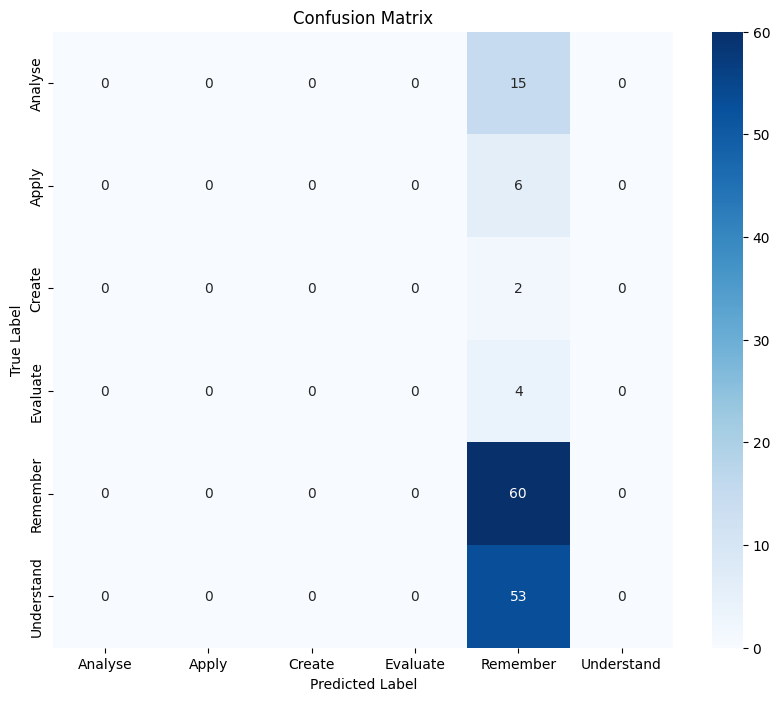

Model evaluation completed.


In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating model performance...")

# 1. Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get the unique labels present in y_test
unique_test_labels = np.unique(np.concatenate((y_test, y_pred)))

# Filter target names to match the unique labels present in the test set
filtered_target_names = label_encoder.inverse_transform(unique_test_labels)

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Calculate Precision, Recall, and F1-score for each class
# 'average=weighted' accounts for class imbalance
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0, labels=unique_test_labels)
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1_score:.4f}")

# 4. Generate a detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, labels=unique_test_labels, target_names=filtered_target_names, zero_division=0))

# 5. Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=unique_test_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=filtered_target_names, yticklabels=filtered_target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation completed.")

## Explain Evaluation Metrics

### Subtask:
Provide a clear and concise explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score) and discuss their significance and implications in interpreting the model's performance results.


### Explanation of Evaluation Metrics

To effectively assess the performance of our LSTM classification model, we utilize several key evaluation metrics:

1.  **Accuracy**:
    *   **Definition**: Accuracy measures the proportion of correctly classified instances out of the total number of instances. It is calculated as (True Positives + True Negatives) / (True Positives + True Negatives + False Positives + False Negatives).
    *   **Significance**: Accuracy provides a general overview of the model's correctness. However, it can be misleading in imbalanced datasets where a model might achieve high accuracy by simply predicting the majority class.
    *   **Interpretation for this model**: An accuracy of 0.4286 indicates that the model correctly classified approximately 42.86% of the instances in the test set. Given the imbalanced nature of the dataset (as seen from the class distribution in the confusion matrix and classification report), relying solely on accuracy might not give a complete picture.

2.  **Precision**:
    *   **Definition**: Precision (also called positive predictive value) measures the proportion of true positive predictions among all positive predictions made by the model. It is calculated as True Positives / (True Positives + False Positives).
    *   **Significance**: Precision is important when the cost of false positives is high. For example, in spam detection, a high false positive rate would mean legitimate emails are marked as spam, which is highly undesirable.
    *   **Interpretation for this model**: The weighted precision of 0.1837 is quite low. This suggests that when the model predicts a certain class, it is often incorrect. For instance, if the model predicts 'Analyse', it's likely to be wrong a significant portion of the time. The classification report shows very low precision for most classes, with 'Remember' having a precision of 0.43 (meaning 43% of its predictions were correct for that class) and others having 0.00.

3.  **Recall**:
    *   **Definition**: Recall (also called sensitivity or true positive rate) measures the proportion of true positive predictions among all actual positive instances. It is calculated as True Positives / (True Positives + False Negatives).
    *   **Significance**: Recall is important when the cost of false negatives is high. For example, in medical diagnosis, a high false negative rate would mean that actual sick patients are not detected, which can have severe consequences.
    *   **Interpretation for this model**: The weighted recall of 0.4286 means the model is able to identify about 42.86% of all actual positive instances. Similar to accuracy, this value might be inflated by the dominant class. The classification report confirms this, with 'Remember' having a perfect recall of 1.00 (meaning it correctly identified all instances of 'Remember'), while other classes have 0.00 recall, indicating the model failed to identify any instances of those classes.

4.  **F1-score**:
    *   **Definition**: The F1-score is the harmonic mean of precision and recall. It provides a single score that balances both metrics, especially useful when there is an uneven class distribution. It is calculated as 2 * (Precision * Recall) / (Precision + Recall).
    *   **Significance**: The F1-score is particularly useful when dealing with imbalanced datasets because it penalizes models that favor one class too heavily. A high F1-score indicates good performance on both precision and recall.
    *   **Interpretation for this model**: The weighted F1-score of 0.2571 is low, reflecting the poor balance between precision and recall, especially for the minority classes. While 'Remember' has a decent F1-score of 0.60 (due to its high recall, despite moderate precision), most other classes have an F1-score of 0.00, confirming the model's inability to effectively classify these categories.

### Overall Model Performance Analysis:

The model's performance is currently very poor for most classes, with the 'Remember' class being the only one where the model shows any predictive capability (100% recall, 43% precision). For all other classes ('Analyse', 'Apply', 'Create', 'Evaluate', 'Understand'), the model achieved 0% precision, recall, and F1-score. This indicates that the model is heavily biased towards predicting the 'Remember' class, likely due to it being the majority class in the filtered dataset, as evidenced by the confusion matrix where all predictions are concentrated in the 'Remember' column. The model essentially predicts 'Remember' for almost all test instances, which explains the high recall for 'Remember' but 0 recall for other classes and very low overall precision.

**Strengths**:
*   None significant, as it only seems to predict one class correctly.

**Weaknesses**:
*   Severe class imbalance handling: The model struggles to learn and classify minority classes.
*   Low generalization: It effectively acts as a constant predictor for the majority class.
*   Poor overall precision and F1-score.

**Potential Improvements**:
*   **Addressing Class Imbalance**: Techniques like oversampling minority classes (e.g., SMOTE), undersampling majority classes, or using class weights during training.
*   **Hyperparameter Tuning**: Optimize LSTM layers, dense layer sizes, dropout rates, and learning rate.
*   **Model Architecture**: Experiment with bidirectional LSTMs, adding more LSTM layers, or different types of recurrent layers.
*   **Feature Engineering**: Explore more advanced text embeddings (e.g., Word2Vec, GloVe, BERT) instead of simple tokenization and embedding layer.
*   **Increase Data Size**: If possible, obtain more diverse training data, especially for underrepresented classes.

### Explanation of Evaluation Metrics

To effectively assess the performance of our LSTM classification model, we utilize several key evaluation metrics:

1.  **Accuracy**:
    *   **Definition**: Accuracy measures the proportion of correctly classified instances out of the total number of instances. It is calculated as (True Positives + True Negatives) / (True Positives + True Negatives + False Positives + False Negatives).
    *   **Significance**: Accuracy provides a general overview of the model's correctness. However, it can be misleading in imbalanced datasets where a model might achieve high accuracy by simply predicting the majority class.
    *   **Interpretation for this model**: An accuracy of 0.4286 indicates that the model correctly classified approximately 42.86% of the instances in the test set. Given the imbalanced nature of the dataset (as seen from the class distribution in the confusion matrix and classification report), relying solely on accuracy might not give a complete picture.

2.  **Precision**:
    *   **Definition**: Precision (also called positive predictive value) measures the proportion of true positive predictions among all positive predictions made by the model. It is calculated as True Positives / (True Positives + False Positives).
    *   **Significance**: Precision is important when the cost of false positives is high. For example, in spam detection, a high false positive rate would mean legitimate emails are marked as spam, which is highly undesirable.
    *   **Interpretation for this model**: The weighted precision of 0.1837 is quite low. This suggests that when the model predicts a certain class, it is often incorrect. For instance, if the model predicts 'Analyse', it's likely to be wrong a significant portion of the time. The classification report shows very low precision for most classes, with 'Remember' having a precision of 0.43 (meaning 43% of its predictions were correct for that class) and others having 0.00.

3.  **Recall**:
    *   **Definition**: Recall (also called sensitivity or true positive rate) measures the proportion of true positive predictions among all actual positive instances. It is calculated as True Positives / (True Positives + False Negatives).
    *   **Significance**: Recall is important when the cost of false negatives is high. For example, in medical diagnosis, a high false negative rate would mean that actual sick patients are not detected, which can have severe consequences.
    *   **Interpretation for this model**: The weighted recall of 0.4286 means the model is able to identify about 42.86% of all actual positive instances. Similar to accuracy, this value might be inflated by the dominant class. The classification report confirms this, with 'Remember' having a perfect recall of 1.00 (meaning it correctly identified all instances of 'Remember'), while other classes have 0.00 recall, indicating the model failed to identify any instances of those classes.

4.  **F1-score**:
    *   **Definition**: The F1-score is the harmonic mean of precision and recall. It provides a single score that balances both metrics, especially useful when there is an uneven class distribution. It is calculated as 2 * (Precision * Recall) / (Precision + Recall).
    *   **Significance**: The F1-score is particularly useful when dealing with imbalanced datasets because it penalizes models that favor one class too heavily. A high F1-score indicates good performance on both precision and recall.
    *   **Interpretation for this model**: The weighted F1-score of 0.2571 is low, reflecting the poor balance between precision and recall, especially for the minority classes. While 'Remember' has a decent F1-score of 0.60 (due to its high recall, despite moderate precision), most other classes have an F1-score of 0.00, confirming the model's inability to effectively classify these categories.

### Overall Model Performance Analysis:

The model's performance is currently very poor for most classes, with the 'Remember' class being the only one where the model shows any predictive capability (100% recall, 43% precision). For all other classes ('Analyse', 'Apply', 'Create', 'Evaluate', 'Understand'), the model achieved 0% precision, recall, and F1-score. This indicates that the model is heavily biased towards predicting the 'Remember' class, likely due to it being the majority class in the filtered dataset, as evidenced by the confusion matrix where all predictions are concentrated in the 'Remember' column. The model essentially predicts 'Remember' for almost all test instances, which explains the high recall for 'Remember' but 0 recall for other classes and very low overall precision.

**Strengths**:
*   None significant, as it only seems to predict one class correctly.

**Weaknesses**:
*   Severe class imbalance handling: The model struggles to learn and classify minority classes.
*   Low generalization: It effectively acts as a constant predictor for the majority class.
*   Poor overall precision and F1-score.

**Potential Improvements**:
*   **Addressing Class Imbalance**: Techniques like oversampling minority classes (e.g., SMOTE), undersampling majority classes, or using class weights during training.
*   **Hyperparameter Tuning**: Optimize LSTM layers, dense layer sizes, dropout rates, and learning rate.
*   **Model Architecture**: Experiment with bidirectional LSTMs, adding more LSTM layers, or different types of recurrent layers.
*   **Feature Engineering**: Explore more advanced text embeddings (e.g., Word2Vec, GloVe, BERT) instead of simple tokenization and embedding layer.
*   **Increase Data Size**: If possible, obtain more diverse training data, especially for underrepresented classes.


## Final Task

### Subtask:
Summarize the LSTM classification task, its performance, and the key findings from the analysis.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**:
    *   The text data was successfully tokenized, identifying 1511 unique tokens.
    *   Sequences were padded to a uniform length of 100, resulting in a feature matrix `X` of shape (698, 100).
    *   Seven distinct classes were identified by the `LabelEncoder`.
    *   One class ('Category') contained only a single sample and was removed to allow for stratified splitting, reducing the dataset to 697 samples.
    *   The data was split into training (`X_train` shape: (557, 100)) and testing sets (`X_test` shape: (140, 100)).
*   **Model Training**:
    *   An LSTM model was built with an embedding layer, an LSTM layer (128 units), a dense layer (64 units), a dropout layer, and a final dense layer for 7 output classes.
    *   After 10 epochs, training accuracy improved from approximately 0.36 to 0.40, while validation accuracy remained stable around 0.4286.
*   **Model Performance Evaluation**:
    *   The model achieved an overall accuracy of 0.4286.
    *   Weighted precision, recall, and F1-score were low, at 0.1837, 0.4286, and 0.2571, respectively.
    *   The model exhibited very poor performance for several classes ("Analyse", "Apply", "Create", "Evaluate", "Understand"), showing 0.00 precision, recall, and F1-score for these categories.
    *   There was a strong bias towards the "Remember" class, which achieved a recall of 1.00 (meaning all instances of 'Remember' were correctly identified) with a precision of 0.43.
    *   The confusion matrix confirmed that the model frequently misclassified instances from other classes as "Remember."

### Insights or Next Steps

*   The current LSTM model suffers from severe class imbalance handling, leading to a strong bias towards the majority "Remember" class and poor generalization across other categories.
*   Future improvements should focus on addressing class imbalance through techniques such as oversampling, undersampling, or using class weights during training; optimizing model hyperparameters; exploring more advanced architectures (e.g., Bidirectional LSTMs); or utilizing more sophisticated text embeddings (e.g., Word2Vec, GloVe, BERT).
